模型準確率: 100.00%


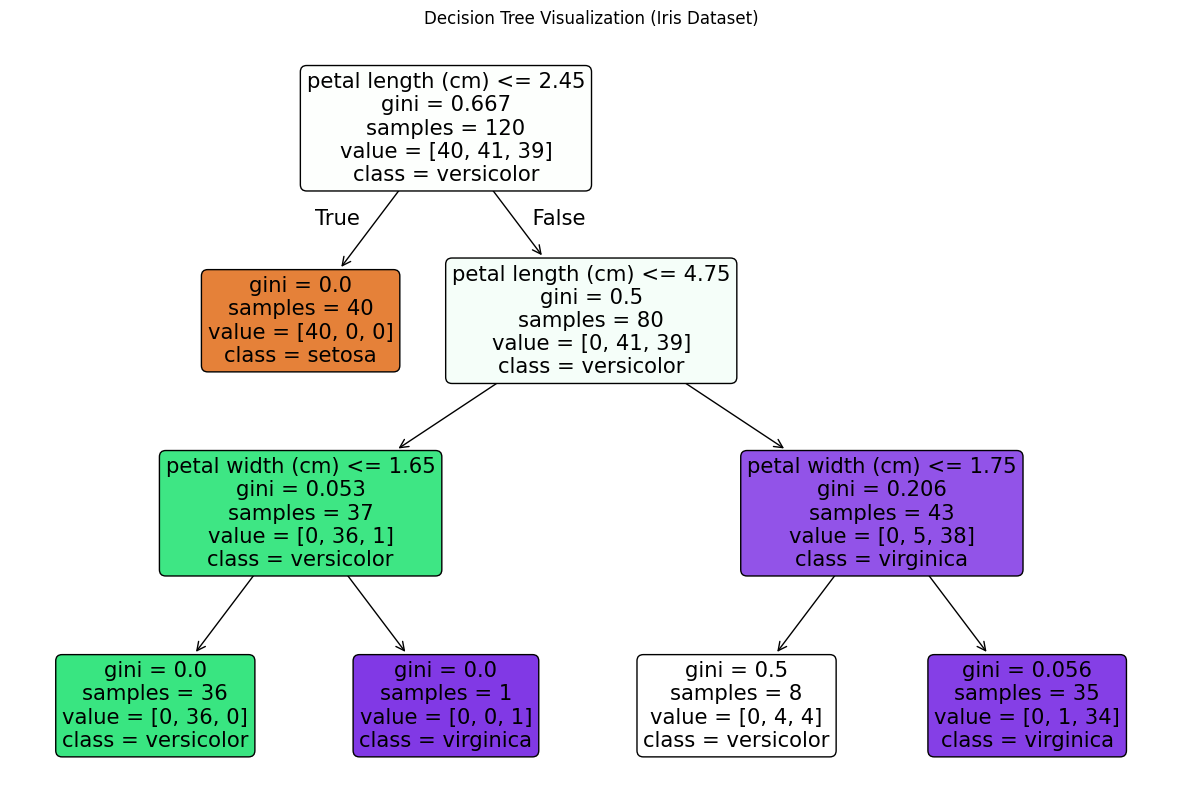

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 載入資料
iris = load_iris()
X, y = iris.data, iris.target

# 將資料拆分為：80% 訓練集, 20% 測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 建立決策樹模型 (限制深度為 3，避免過度擬合並方便觀察)
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# 進行預測
y_pred = clf.predict(X_test)
print(f"模型準確率: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 2. 視覺化決策樹的判斷邏輯
plt.figure(figsize=(15, 10))
plot_tree(clf,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True)
plt.title("Decision Tree Visualization (Iris Dataset)")
plt.show()

In [ ]:
import pandas as pd
pd.DataFrame(iris.data, columns=iris.feature_names).head()

AttributeError: head

In [ ]:
# Colab 進行matplotlib繪圖時顯示繁體中文
# 下載台北思源黑體並命名taipei_sans_tc_beta.ttf，移至指定路徑
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib

# 改style要在改font之前
# plt.style.use('seaborn')

matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')

--2026-03-11 18:47:15--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 64.233.179.100, 64.233.179.101, 64.233.179.139, ...
Connecting to drive.google.com (drive.google.com)|64.233.179.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2026-03-11 18:47:15--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.69.132, 2607:f8b0:4001:c08::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.69.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M  47.3MB/s    in 0.4s    

2026-03-11 18:47:17

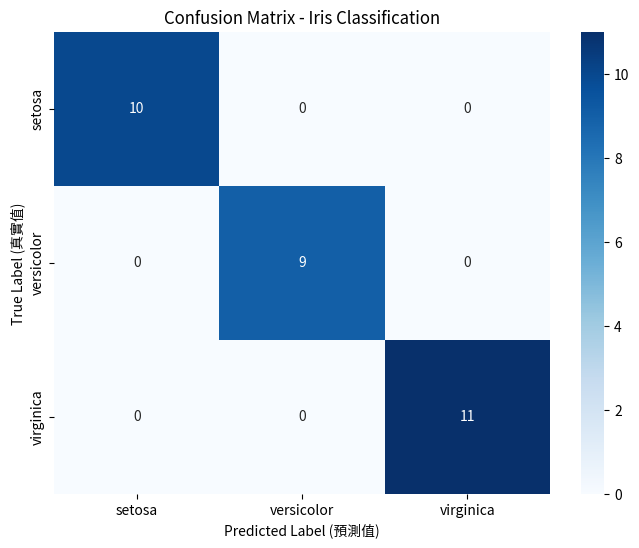

--- 詳細分類報告 (Classification Report) ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 產生預測結果 (延續上一個回覆的 clf 與 X_test)
y_pred = clf.predict(X_test)

# 2. 計算混淆矩陣
cm = confusion_matrix(y_test, y_pred)

# 3. 繪製混淆矩陣熱力圖
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Predicted Label (預測值)')
plt.ylabel('True Label (真實值)')
plt.title('Confusion Matrix - Iris Classification')
plt.show()

# 4. 顯示詳細分類報告
print("--- 詳細分類報告 (Classification Report) ---")
print(classification_report(y_test, y_pred, target_names=iris.target_names))